# Simulations for MacArthur consumer-resource model

This notebook contains simulations for MacArthur consumer-resource model that generate the results in SI Sec. E. See SI Sec. B for model definition.

In [139]:
import numpy as np
import cvxpy as cp
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from collections import defaultdict
import scipy as sp
from sklearn.linear_model import LinearRegression
from joblib import Parallel, delayed
import pickle
from tqdm import tqdm

## Sampling of community, parent, and mutant

In [141]:
# Model parameters

S = 50
M = 50
mu = 2
sigma = 0.8
mu_k = 5
sigma_k = 0.5
mu_m = 2
sigma_m = 0.2
kappa = 1
threshold = 10 ** -7

In [143]:
# Sample interactions and other parameters

zc = np.random.normal(size=(S, M))
ze = kappa * zc + np.sqrt(1 - kappa ** 2) * np.random.normal(size=(S, M))
C = mu / M + sigma / np.sqrt(M) * zc
E = mu / M + sigma / np.sqrt(M) * ze
K = np.random.normal(loc=mu_k, scale=sigma_k, size=M)
m = np.random.normal(loc=mu_m, scale=sigma_m, size=S)

In [145]:
# Find initial steady state

def find_steady_state(K, m, C, E, S, M, migration_rate=10 ** -10, t_max=1000000):
    def derivative(t, y):
        dNdt = y[:S] * (C @ y[S:] - m) + migration_rate
        dRdt = y[S:] * (K - y[S:] - E.T @ y[:S]) + migration_rate
        return np.concatenate((dNdt, dRdt))

    def check_steady_state(t, y): 
        return np.max(np.abs(derivative(t, y))) > migration_rate

    # Integrate until steady state or t_max is reached
    check_steady_state.terminal = True
    sol = sp.integrate.solve_ivp(derivative, t_span=(0, t_max), y0=np.random.rand(S + M), method='LSODA', atol=1e-12, rtol=1e-12, events=[check_steady_state])
    
    # Check if the integration reached the maximum time
    time_limit_reached = (sol.t[-1] == t_max)
    if time_limit_reached:
        raise Exception('It doesn\'t converge...🥲')

    return sol.y.T[-1][:S], sol.y.T[-1][S:]

n0, r0 = find_steady_state(K, m, C, E, S, M)

In [149]:
# Sample interaction matrices with mutant

def mutant(parent, rho_mutant):
    zc_p = (C[parent] - mu / M) / (sigma / np.sqrt(M))
    ze_p = (E[parent] - mu / M) / (sigma / np.sqrt(M))
    z1, z2 = np.random.normal(size=len(r0)), np.random.normal(size=len(r0))
    zc_m = rho_mutant * zc_p + np.sqrt(1 - rho_mutant ** 2) * z1
    ze_m = rho_mutant * ze_p + np.sqrt(1 - rho_mutant ** 2) * (kappa * z1 + np.sqrt(1 - kappa ** 2) * z2)
    C_m = mu / M + sigma / np.sqrt(M) * zc_m
    E_m = mu / M + sigma / np.sqrt(M) * ze_m
    C_invade = np.vstack((C, C_m))
    E_invade = np.vstack((E, E_m))
    return C_invade, E_invade

## Simulations of dynamics

In [206]:
# Simulate the CRM with demographic noise after mutation

def simulate(n0, r0, parent, delta_m, C_invade, E_invade, temperature, t_final=10000, portion=0.1, plot=False, plot_trial=False):
    # Initialization
    m_0 = m[parent] + delta_m
    m_invade = np.append(m, m_0)
    
    n = np.append(n0, portion * n0[parent])
    n[n < threshold] = threshold
    r = r0.copy()
    r[r < threshold] = threshold

    n_evolution = [n.copy()]
    r_evolution = [r.copy()]
    fraction = [n[-1] / (n[parent] + n[-1])]
    n_pm_sum = [n[parent] + n[-1]]
    Cr = C_invade @ r
    delta_s = [Cr[-1] - Cr[parent] - delta_m]

    # Forward integration
    dt = 0.1
    res = -1
    for time_step in range(int(t_final / dt)):
        Cr = C_invade @ r
        growth_rate = Cr - m_invade
        # Method from cond-mat/0404105
        lambda_param = growth_rate / (np.exp(growth_rate * dt) - 1) / temperature
        alpha = np.random.poisson(lam=(lambda_param * n * np.exp(growth_rate * dt)))
        r += r * (K - r - E_invade.T @ n) * dt
        r[r < threshold] = threshold
        # Choice: whether to include noise for resources
        # growth_rate_r = K - r - E_invade.T @ n
        # lambda_param_r = growth_rate_r / (np.exp(growth_rate_r * dt) - 1) / temperature
        # alpha_r = np.random.poisson(lam=(lambda_param_r * r * np.exp(growth_rate_r * dt)))
        n[alpha == 0] = threshold
        n[alpha > 0] = np.random.gamma(alpha[alpha > 0]) / lambda_param[alpha > 0]
        n[n < threshold] = threshold
        # r[alpha_r == 0] = threshold
        # r[alpha_r > 0] = np.random.gamma(alpha_r[alpha_r > 0]) / lambda_param_r[alpha_r > 0]
        # r[r < threshold] = threshold

        # Stop simulation after absorption
        if n[parent] <= threshold:
            res = 1
            break
        if n[-1] <= threshold:
            res = 0
            break
        # Save data for plots
        if plot or plot_trial:
            n_evolution.append(n.copy())
            r_evolution.append(r.copy())
            fraction.append(n[-1] / (n[-1] + n[parent]))
            n_pm_sum.append(n[parent] + n[-1])
            delta_s.append(Cr[-1] - Cr[parent] - delta_m)

    # Process plot data
    plot_data = {}
    x_axis = np.linspace(0, dt * time_step, time_step + 1)
    if plot or plot_trial:
        plot_data['x_axis'] = x_axis
        plot_data['Outcome'] = res
        plot_data['Species abundances'] = np.array(n_evolution)
        plot_data['Resource abundances'] = np.array(r_evolution)
        plot_data['Log mutant fraction'] = np.log(fraction)
        plot_data['Parent + mutant abundance'] = n_pm_sum
        plot_data['Invasion fitness difference'] = delta_s

    # Plot the data
    if plot:
        n_evolution = np.array(n_evolution)
        r_evolution = np.array(r_evolution)
        
        plt.plot(x_axis, n_evolution, alpha=0.5)
        plt.plot(x_axis, n_evolution[:, parent], c='black', linestyle='dashed', label='parent')
        plt.plot(x_axis, n_evolution[:, -1], c='blue', linestyle='dashed', label='mutant')
        # plt.axhline(n_invade[parent], c='black', linestyle='dotted', label='parent_steady')
        # plt.axhline(n_invade[-1], c='blue', linestyle='dotted', label='mutant_steady')
        plt.legend()
        plt.xlabel('t')
        plt.ylabel('N')
        plt.show()

        plt.plot(x_axis, r_evolution, alpha=0.5)
        plt.xlabel('t')
        plt.ylabel('R')
        plt.show()

        for name in plot_data:
            if name in ['x_axis', 'Outcome', 'Species abundances', 'Resource abundances']:
                continue
            plt.plot(x_axis, plot_data[name])
            plt.xlabel('t')
            plt.ylabel(name)
            plt.show()

    if plot_trial:
        return plot_data
        
    return res

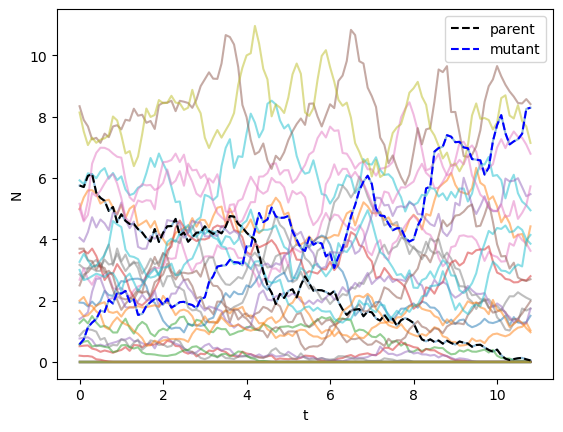

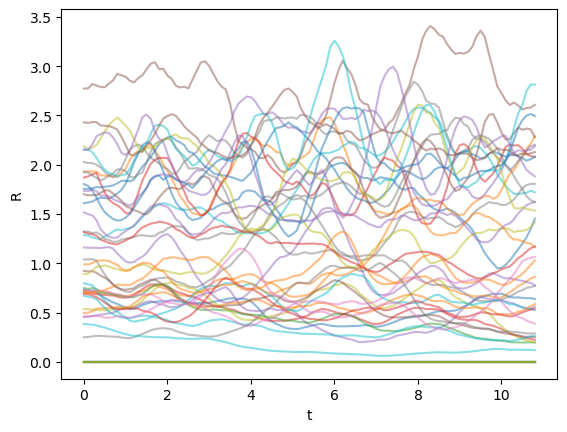

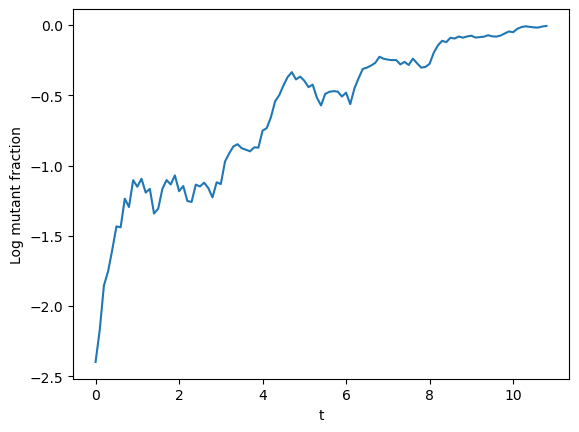

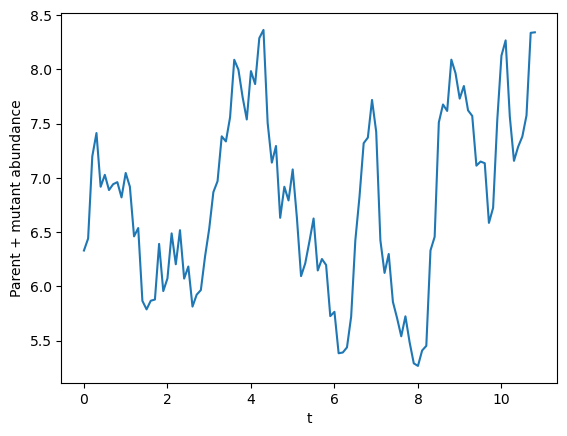

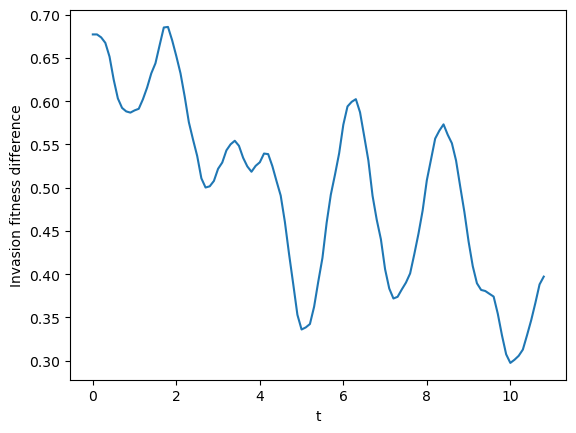

1

In [124]:
parent = 0
C_invade, E_invade = mutant(parent, 0.9)
Cr = C_invade @ r0
simulate(n0, r0, parent, 0, C_invade, E_invade, 0.1, portion=0.1, plot=True)

## Fixation probability

In [153]:
# Find fixation probability using simulation trials

def fixation_probability(n0, r0, parent, delta_m, C_invade, E_invade, temperature, trial=1000, t_final=10000, portion=0.1):
    remaining = trial
    fixation_count = 0
    while remaining > 0:
        res = simulate(n0, r0, parent, delta_m, C_invade, E_invade, temperature, t_final, portion)
        if res > -1:
            remaining -= 1
            fixation_count += res
        else:
            print('They coexisted...🥲')
    return fixation_count / trial

In [155]:
# Find fixation probability grouped by amount of resource extinction

def fixation_probability_by_extinction(n0, r0, parent, delta_m, C_invade, E_invade, temperature, trial=1000, t_final=10000, portion=0.1):
    res = Parallel(n_jobs=-2)(delayed(simulate)(n0, r0, parent, delta_m, C_invade, E_invade, temperature, t_final, portion, False, True) for i in range(trial))
    counts = defaultdict(lambda: [0, 0]) # [number of fixation, number of trials]
    for plot_data in res:
        if plot_data['Outcome'] == -1:
            continue
        r_extinction = sum(r0 > threshold) - sum(plot_data['Resource abundances'][-1] > threshold)
        counts[r_extinction][0] += plot_data['Outcome']
        counts[r_extinction][1] += 1
    probs = {}
    for r_extinction in counts:
        probs[r_extinction] = counts[r_extinction][0] / counts[r_extinction][1]
    
    return probs

Since the dynamics is more complicated and our theory is less accurate, we explore different definitions of s

In [171]:
# Fixation probability for different mutants and s

# Modes for defining s:
# - none: initial fitness difference
# - r_extinct: including correction from resource extinction at steady state
# - invader_N: inferred from invader abundance at steady state

def run_trial(n0, r0, parent, s_list, temperature, rho_mutant=0.9, portion=0.1, mode=None, allow_r_extinction=True, allow_n_extinction=True):
    while True:
        C_invade, E_invade = mutant(parent, rho_mutant)
        Cr = C_invade @ r0
        delta_m_list = Cr[-1] - Cr[parent] - s_list
        delta_m = min(delta_m_list)
        m_0 = m[parent] + delta_m
        m_invade = np.append(m, m_0)

        # Check if there is species or resource extinction at steady state
        nf, rf = find_steady_state(K, m_invade, C_invade, E_invade, S + 1, M)
        n0_community = np.delete(n0, parent)
        nf_community = np.delete(nf, [parent, -1])
        n_extinction = (n0_community > threshold) & (nf_community < threshold)
        r_extinction = (r0 > threshold) & (rf < threshold)
        if (sum(r_extinction) == 0 or allow_r_extinction) and (sum(n_extinction) == 0 or allow_n_extinction):
            break
    if mode == 'r_extinct':
        # Use iterative algorithm to find delta_m and the corresponding resource extinction that gives the desired s
        corrected_delta_m_list = []
        for delta_m in delta_m_list:
            correction = 0
            trial = 0
            trial_limit = 10
            while trial < trial_limit:
                m_0 = m[parent] + delta_m - correction
                m_invade = np.append(m, m_0)
                nf, rf = find_steady_state(K, m_invade, C_invade, E_invade, S + 1, M)
                r_extinction = (r0 > threshold) & (rf < threshold)
                if abs(correction - C_invade[-1, r_extinction] @ r0[r_extinction]) < 10 ** -6:
                    break
                correction = C_invade[-1, r_extinction] @ r0[r_extinction]
                trial += 1
            if trial == trial_limit:
                print('R_extinct does not converge!')
                return [np.nan] * len(delta_m_list)
            corrected_delta_m_list.append(delta_m - correction)
        delta_m_list = corrected_delta_m_list
    elif mode == 'invader_N':
        # Use binary search to find delta_m that gives the desired invader abundance
        n_survivor = (n0 > threshold)
        r_survivor = (r0> threshold)
        C_survive = C[n_survivor, :][:, r_survivor]
        E_survive = E[n_survivor, :][:, r_survivor]
        M_survive = sum(r_survivor)
        susceptibility = np.trace(np.identity(M_survive) - E_survive.T @ np.linalg.inv(C_survive @ E_survive.T) @ C_survive) / M
        Npm = n0[parent] * (1 + portion)
        eta = 2 * Npm * (1 - rho_mutant) * kappa * (sigma ** 2) * susceptibility
        corrected_delta_m_list = []
        for s in s_list:
            delta_m = Cr[-1] - Cr[parent] - s
            if s <= 0:
                corrected_delta_m_list.append(delta_m)
                continue
            l, r = -5, 5
            target = s * Npm / eta
            while r - l > 10 ** -6:
                delta_m = (l + r) / 2
                m_0 = m[parent] + delta_m
                m_invade = np.append(m, m_0)
                nf, rf = find_steady_state(K, m_invade, C_invade, E_invade, S + 1, M)
                if abs(nf[-1] - target) < 10 ** -4:
                    l = delta_m
                    break
                if nf[-1] > target:
                    l = delta_m
                else:
                    r = delta_m
            corrected_delta_m_list.append(l)
        delta_m_list = corrected_delta_m_list
    probs = [fixation_probability(n0, r0, parent, delta_m, C_invade, E_invade, temperature, portion=portion) for delta_m in tqdm(delta_m_list)]
    return probs

In [159]:
# Fixation probability for different mutants and s, with all definitions of s
# Each definition results in different sets of s

def run_trial_all_mode(n0, r0, parent, s_list, temperature, rho_mutant=0.9, portion=0.1):
    C_invade, E_invade = mutant(parent, rho_mutant)
    Cr = C_invade @ r0
    delta_m_list = Cr[-1] - Cr[parent] - s_list
    r_extinction_s_list = []
    invader_n_s_list = []
    for delta_m in delta_m_list:
        # Mode with resource extinction
        s = Cr[-1] - Cr[parent] - delta_m
        m_0 = m[parent] + delta_m
        m_invade = np.append(m, m_0)
        nf, rf = find_steady_state(K, m_invade, C_invade, E_invade, S + 1, M)
        r_extinction = (r0 > threshold) & (rf < threshold)
        r_extinction_s_list.append(s - C_invade[-1, r_extinction] @ r0[r_extinction])

        # Mode with invader abundance for positive s
        if s <= 0:
            invader_n_s_list.append(s)
        else:
            n_survivor = (n0 > threshold)
            r_survivor = (r0 > threshold)
            C_survive = C[n_survivor, :][:, r_survivor]
            E_survive = E[n_survivor, :][:, r_survivor]
            M_survive = sum(r_survivor)
            susceptibility = np.trace(np.identity(M_survive) - E_survive.T @ np.linalg.inv(C_survive @ E_survive.T) @ C_survive) / M
            Npm = n0[parent] * (1 + portion)
            eta = 2 * Npm * (1 - rho_mutant) * kappa * (sigma ** 2) * susceptibility
            invader_n_s_list.append(nf[-1] * eta / Npm)
    probs = [fixation_probability(n0, r0, parent, delta_m, C_invade, E_invade, temperature, portion=portion) for delta_m in tqdm(delta_m_list)]
    return s_list, r_extinction_s_list, invader_n_s_list, probs

In [161]:
# Fixation probability for different mutants and s, grouped by amount of resource extinction

def run_trial_by_extinction(n0, r0, parent, s_list, temperature, rho_mutant=0.9, portion=0.1):
    C_invade, E_invade = mutant(parent, rho_mutant)
    Cr = C_invade @ r0
    delta_m_list = Cr[-1] - Cr[parent] - s_list
    probs = [fixation_probability_by_extinction(n0, r0, parent, delta_m, C_invade, E_invade, temperature, portion=portion) for delta_m in tqdm(delta_m_list)]
    return probs

In [163]:
# Analytical formulas for fixation probability

# Kimura's formula
def fix_prob_theory(p, N, s):
    return (1 - np.exp(-N * s * p)) / (1 - np.exp(-N * s))

# Theory with ecology
def corrected_fix_prob_theory(p, N, a, s):
    def helper(x):
        return sp.special.erfi((a * x + s) * np.sqrt(N / 2 / a))
    return (helper(p) - helper(0)) / (helper(p) - helper(p - 1))

In [198]:
# Generate data for Figure S1

parent = 2
s_range = {
    0.1: np.linspace(-0.1, 0.5, 20),
}
portion = 0.1
plot_catalog = {}
for temperature in s_range:
    plot_catalog[temperature] = Parallel(n_jobs=-2)(delayed(run_trial)(n0, r0, parent, s_range[temperature], temperature, portion=portion, allow_r_extinction=False, allow_n_extinction=False) for i in range(10))

results = {
    'S': S,
    'M': M,
    'mu': mu,
    'sigma': sigma,
    'mu_k': mu_k,
    'sigma_k': sigma_k,
    'mu_m': mu_m,
    'sigma_m': sigma_m,
    'kappa': kappa,
    'temperature': list(s_range.keys()),
    'rho_mutant': 0.9,
    'portion': portion,
    'n0': n0,
    'r0': r0,
    'C': C,
    'E': E,
    'parent': parent,
    's': s_range,
    'data': plot_catalog,
}

with open('ecopopgenfig/fixation_prob_crm_no_nr_extinction.pkl', 'wb') as f:
    pickle.dump(results, f)

100%|██████████| 20/20 [04:55<00:00, 14.79s/it]


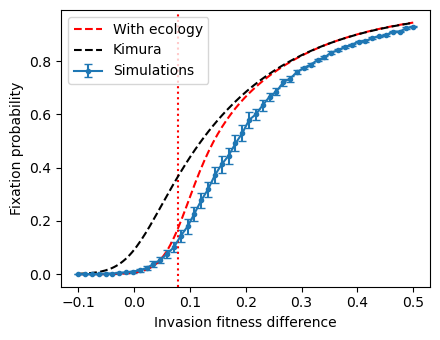

In [173]:
# Plots to compare theory and simulation

with open('ecopopgenfig/fixation_prob_crm.pkl', 'rb') as f:
    results = pickle.load(f)

portion = results['portion']

TAP = results['kappa'] * results['sigma'] ** 2 * (sum(results['r0'] > threshold) - sum(results['n0'] > threshold)) / results['M']
portion = results['portion']
Npm = results['n0'][results['parent']] * (1 + portion)
eta = 2 * Npm * (1 - results['rho_mutant']) * TAP

for temperature in results['data']:
    plt.figure(figsize=(4.5,3.5))
    trials = np.array(results['data'][temperature])
    s_list = np.array(results['s'][temperature])
    s_samples = np.linspace(np.min(s_list), np.max(s_list), 150)
    mean_probs = np.nanmean(trials, axis=0)
    err_probs = np.nanstd(trials, axis=0) / np.sqrt(np.sum(~np.isnan(trials), axis=0))
    plt.errorbar(s_list, mean_probs, yerr=err_probs, fmt='o-', markersize=3, capsize=3, label='Simulations')


    N_eff = Npm / temperature
    p_theory = corrected_fix_prob_theory(portion / (1 + portion), N_eff, eta, s_samples)
    plt.plot(s_samples, p_theory, c='red',linestyle='dashed', label='With ecology')
    plt.axvline(eta * (1 / 2 - portion / (1 + portion)), c='red', linestyle='dotted')
    
    p_theory = fix_prob_theory(portion / (1 + portion), N_eff, s_samples)
    plt.plot(s_samples, p_theory, c='black',linestyle='dashed', label='Kimura')
    
    plt.xlabel('Invasion fitness difference')
    plt.ylabel('Fixation probability')
    # plt.yscale('log')
    plt.legend(loc='upper left')
    plt.tight_layout()
    plt.show()

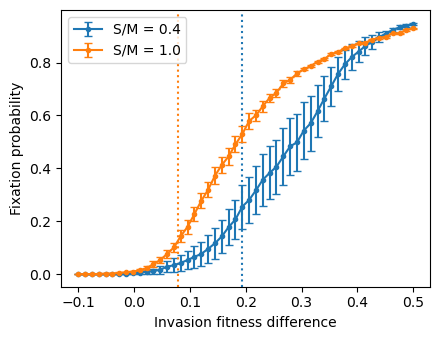

In [336]:
# Plot to compare fixation probability at different packing S*/M* (Figure S2)

with open('ecopopgenfig/fixation_prob_crm_less_packed.pkl', 'rb') as f:
    results = pickle.load(f)

plt.figure(figsize=(4.5,3.5))

portion = results['portion']
n_survivor = (results['n0'] > threshold)
r_survivor = (results['r0'] > threshold)
C_survive = results['C'][n_survivor, :][:, r_survivor]
E_survive = results['E'][n_survivor, :][:, r_survivor]
M = results['M']
M_survive = sum(r_survivor)
susceptibility = np.trace(np.identity(M_survive) - E_survive.T @ np.linalg.inv(C_survive @ E_survive.T) @ C_survive) / M
portion = results['portion']
Npm = results['n0'][results['parent']] * (1 + portion)
eta = 2 * Npm * (1 - results['rho_mutant']) * results['kappa'] * (results['sigma'] ** 2) * susceptibility

for temperature in results['data']:
    trials = np.array(results['data'][temperature])
    s_list = np.array(results['s'][temperature])
    mean_probs = np.nanmean(trials, axis=0)
    err_probs = np.nanstd(trials, axis=0) / np.sqrt(np.sum(~np.isnan(trials), axis=0))
    plt.errorbar(s_list, mean_probs, yerr=err_probs, fmt='o-', markersize=3, capsize=3, label=f'S/M = {results['S'] / results['M']:.1f}')
    plt.axvline(eta * (1 / 2 - portion / (1 + portion)), c='C0', linestyle='dotted')

with open('ecopopgenfig/fixation_prob_crm.pkl', 'rb') as f:
    results = pickle.load(f)

portion = results['portion']
n_survivor = (results['n0'] > threshold)
r_survivor = (results['r0'] > threshold)
C_survive = results['C'][n_survivor, :][:, r_survivor]
E_survive = results['E'][n_survivor, :][:, r_survivor]
M = results['M']
M_survive = sum(r_survivor)
susceptibility = np.trace(np.identity(M_survive) - E_survive.T @ np.linalg.inv(C_survive @ E_survive.T) @ C_survive) / M
portion = results['portion']
Npm = results['n0'][results['parent']] * (1 + portion)
eta = 2 * Npm * (1 - results['rho_mutant']) * results['kappa'] * (results['sigma'] ** 2) * susceptibility

for temperature in results['data']:
    trials = np.array(results['data'][temperature])
    s_list = np.array(results['s'][temperature])
    mean_probs = np.nanmean(trials, axis=0)
    err_probs = np.nanstd(trials, axis=0) / np.sqrt(np.sum(~np.isnan(trials), axis=0))
    plt.errorbar(s_list, mean_probs, yerr=err_probs, fmt='o-', markersize=3, capsize=3, label=f'S/M = {results['S'] / results['M']:.1f}')
    plt.axvline(eta * (1 / 2 - portion / (1 + portion)), c='C1', linestyle='dotted')

plt.xlabel('Invasion fitness difference')
plt.ylabel('Fixation probability')
# plt.yscale('log')
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

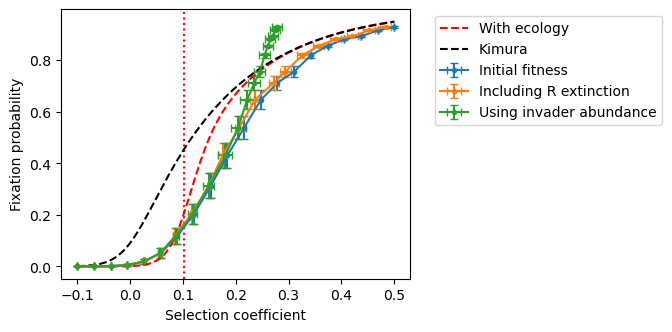

In [136]:
# Compare theory and simulation with all definitions of s

with open('ecopopgenfig/fixation_prob_crm_all_mode.pkl', 'rb') as f:
    results = pickle.load(f)

portion = results['portion']

TAP = results['kappa'] * results['sigma'] ** 2 * (sum(results['r0'] > threshold) - sum(results['n0'] > threshold)) / results['M']
portion = results['portion']
Npm = results['n0'][results['parent']] * (1 + portion)
eta = 2 * Npm * (1 - results['rho_mutant']) * TAP

for temperature in results['data']:
    plt.figure(figsize=(4.5,3.5))
    for i, label in enumerate(['Initial fitness', 'Including R extinction', 'Using invader abundance']):
        data = np.array(results['data'][temperature])
        trials = data[:, -1]
        s_list = data[:, i]
        mean_probs = np.nanmean(trials, axis=0)
        err_probs = np.nanstd(trials, axis=0) / np.sqrt(np.sum(~np.isnan(trials), axis=0))
        mean_s = np.mean(s_list, axis=0)
        err_s = np.std(s_list, axis=0) / np.sqrt(len(s_list))
        plt.errorbar(mean_s, mean_probs, xerr=err_s, yerr=err_probs, fmt='o-', markersize=3, capsize=3, label=label)

    s_samples = np.linspace(np.min(results['s'][temperature]), np.max(results['s'][temperature]), 150)
    N_eff = Npm / temperature
    p_theory = corrected_fix_prob_theory(portion / (1 + portion), N_eff, eta, s_samples)
    plt.plot(s_samples, p_theory, c='red',linestyle='dashed', label='With ecology')
    plt.axvline(eta * (1 / 2 - portion / (1 + portion)), c='red', linestyle='dotted')
    
    p_theory = fix_prob_theory(portion / (1 + portion), N_eff, s_samples)
    plt.plot(s_samples, p_theory, c='black',linestyle='dashed', label='Kimura')
    
    plt.xlabel('Selection coefficient')
    plt.ylabel('Fixation probability')
    # plt.yscale('log')
    plt.legend(loc='upper left', bbox_to_anchor=(1.05, 1))
    plt.show()